<a href="https://colab.research.google.com/github/davidpalacio1/TP-2-LDD/blob/main/TP2_EPH_portfolio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis del Mercado Laboral Argentino — Encuesta Permanente de Hogares (EPH)
##  Laboratorio de Datos - Trabajo práctico

**Universidad de Buenos Aires · Facultad de Ciencias Exactas y Naturales (FCEyN)**

---

### Descripción del proyecto

Analizamos la **Encuesta Permanente de Hogares (EPH)** del tercer trimestre de 2025, relevada por el INDEC. La EPH es la principal fuente de información laboral de Argentina: registra datos socioeconómicos de 44.946 individuos en los principales aglomerados urbanos.

El análisis se organiza en tres bloques:

1. **Limpieza y preprocesamiento** — filtrado, imputación, codificación dummy y recodificación.
2. **Clustering (no supervisado)** — PCA + K-Means para identificar perfiles socioeconómicos.
3. **Clasificación y Regresión (supervisado)** — KNN para predecir sector de empleo y Ridge para predecir ingreso.

**Dataset:** `usu_individual_T325.txt` — Base de personas, EPH T3-2025 (INDEC)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import (
    mean_squared_error, r2_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})


---
# Limpieza y preprocesamiento de datos

La base de personas EPH T3-2025 contiene 235 variables y 44.946 registros. En esta sección la llevamos a un formato apropiado para el análisis, documentando cada decisión metodológica.

## 1. Carga de datos

In [ ]:
df = pd.read_csv('usu_individual_T325.txt', sep=';')
print(f'Dimensiones iniciales: {df.shape[0]:,} filas × {df.shape[1]} columnas')


Dimensiones iniciales: 44,946 filas × 235 columnas


## 2. Filtrado de entrevistas completas

`H15 = 1` indica que la entrevista individual fue realizada correctamente. Descartamos los registros con entrevista incompleta ya que no brindan información confiable.

In [ ]:
n_inicial = len(df)
df = df[df['H15'] == 1].copy()
print(f'Entrevistas completas: {len(df):,}')
print(f'Descartadas (incompletas): {n_inicial - len(df):,} ({(n_inicial-len(df))/n_inicial:.1%})')


Entrevistas completas: 39,999
Descartadas (incompletas): 4,947 (11.0%)


Se descartan 4.947 registros (11.0%), quedando **39.999 individuos**.

## 3. Selección de columnas

Retenemos las variables relevantes e incorporamos `EMPLEO` desde el inicio para evitar releer el archivo más adelante.

In [ ]:
columnas_seleccionadas = [
    'EMPLEO',
    'REGION', 'MAS_500', 'CH04', 'CH03', 'CH06', 'CH07', 'CH09', 'CH10',
    'NIVEL_ED', 'ESTADO', 'CAT_OCUP', 'CAT_INAC', 'SECTOR',
    'PP02B', 'PP02C1', 'PP02C2', 'PP02C3', 'PP02C4', 'PP02C5',
    'PP02C6', 'PP02C7', 'PP02C8', 'PP02D', 'PP02F', 'PP02G',
    'PP02H', 'PP02I', 'PP03C', 'PP03D', 'PP3E_TOT', 'PP3F_TOT',
    'PP03G', 'PP03H', 'PP04A', 'PP04A1', 'PP04B1', 'PP04B2',
    'PP04B3_ANO', 'PP04C', 'PP03I', 'PP03J', 'PP03K',
    'INTENSI', 'PP04G', 'P47T'
]
df = df[columnas_seleccionadas].copy()
print(f'Variables seleccionadas: {df.shape[1]} | Filas: {df.shape[0]:,}')


Variables seleccionadas: 46 | Filas: 39,999


## 4. Imputación de valores faltantes

In [ ]:
columnas_a_imputar = [
    'EMPLEO', 'PP03C', 'PP03D', 'PP3E_TOT', 'PP3F_TOT',
    'PP03G', 'PP03H', 'PP03I', 'PP03J', 'PP03K',
    'PP04B1', 'PP04B2', 'PP04B3_ANO', 'PP04C',
    'PP04A', 'PP04A1', 'PP04G', 'INTENSI'
]
df[columnas_a_imputar] = df[columnas_a_imputar].fillna(0)

faltantes = df.isna().sum()
print('Columnas con valores faltantes tras imputación:')
print(faltantes[faltantes > 0].to_string() if faltantes.sum() > 0 else '  Ninguna ✓')


Columnas con valores faltantes tras imputación:
SECTOR    19933


## 5. Valores faltantes en P47T

In [ ]:
faltantes_p47t = df['P47T'].isna().sum()
if faltantes_p47t == 0:
    print('P47T no presenta valores faltantes ✓')
else:
    df = df.dropna(subset=['P47T'])
    print(f'Eliminadas {faltantes_p47t} filas con P47T ausente.')


P47T no presenta valores faltantes ✓


## 6. Análisis de valores faltantes en SECTOR

`SECTOR` clasifica el sector laboral **exclusivamente para personas ocupadas** (1=Formal, 2=Informal, 3=Servicio doméstico, 9=NS/NR). Su ausencia en desocupados e inactivos es **estructural**, no un error de datos. Eliminar esas filas descartaría ~50% del dataset introduciendo sesgo grave. **Decisión: conservamos todas las filas** para clustering. En clasificación (Ej. 14) filtraremos por sectores.

In [ ]:
faltantes_sector = df['SECTOR'].isna().sum()
print(f'Filas con SECTOR ausente: {faltantes_sector:,} ({faltantes_sector/len(df):.1%})')
print(f'Distribución de SECTOR (valores presentes):')
print(df['SECTOR'].value_counts().sort_index().to_string())


Filas con SECTOR ausente: 19,933 (49.8%)
Distribución de SECTOR (valores presentes):
SECTOR
1.0    13224
2.0     4711
3.0     1417
9.0      714


## 7. Codificación dummy

Las variables categóricas nominales no tienen relación numérica entre categorías. Usamos `drop_first=True` para evitar multicolinealidad perfecta.

**No se convierten a dummy:** `SECTOR` (variable objetivo en clasificación), `PP3E_TOT` y `PP3F_TOT` (horas trabajadas, cuantitativas continuas).

**Nota técnica:** en versiones modernas de pandas, `get_dummies` genera columnas de tipo `bool`. Las convertimos a `int` (0/1) para garantizar compatibilidad con scikit-learn.

In [ ]:
variables_categoricas = [
    'ESTADO', 'REGION', 'MAS_500', 'CAT_OCUP', 'CAT_INAC',
    'PP02B', 'PP02C1', 'PP02C2', 'PP02C3', 'PP02C4',
    'PP02C5', 'PP02C6', 'PP02C7', 'PP02C8',
    'PP02D', 'PP02F', 'PP02G', 'PP02H', 'PP02I',
    'PP03C', 'PP03D', 'PP03G', 'PP03H', 'PP03I',
    'PP03J', 'PP03K', 'INTENSI', 'PP04A', 'PP04A1', 'PP04G'
]

df = pd.get_dummies(df, columns=variables_categoricas, drop_first=True)

# Convertimos bool → int para tener compatibilidad con scikit-learn:

bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

print(f'Dimensiones tras codificación: {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'Tipos no numéricos restantes: {df.select_dtypes(exclude="number").shape[1]} ✓')


Dimensiones tras codificación: 39,999 filas × 113 columnas
Tipos no numéricos restantes: 0 ✓


## 8. Transformaciones adicionales

In [ ]:
df_clean = df.copy()


### (a) Estado civil → SOLTERO

Se tiene para `CH07`: 1=Unido, 2=Casado, 3=Separado, 4=Viudo, **5=Soltero**. Reemplazamos por una variable que indique si es soltero o no, disminiyunde el uso de dummies.

In [ ]:
df_clean['SOLTERO'] = (df_clean['CH07'] == 5).astype(int)
df_clean = df_clean.drop(columns=['CH07'])
print(f'Solteros: {df_clean["SOLTERO"].sum():,} ({df_clean["SOLTERO"].mean():.1%})')


Solteros: 17,949 (44.9%)


El 45.3% de los individuos es soltero, coherente con la estructura demográfica urbana argentina.

### (b) Alfabetismo → LEE

`CH09`: 1=Sabe leer, 2=No, 3=Menor de 2 años. Reemplazamos por una variable que solo indique si sabe leer o no.

In [ ]:
df_clean['LEE'] = (df_clean['CH09'] == 1).astype(int)
df_clean = df_clean.drop(columns=['CH09'])
print(f'Saben leer: {df_clean["LEE"].sum():,} ({df_clean["LEE"].mean():.1%})')


Saben leer: 39,610 (99.0%)


El 99.0% sabe leer, consistente con las tasas de alfabetización en áreas urbanas de Argentina.

### (c) Eliminación de PP04C = 99 (NS/NR)

Eliminamos a los individuos que no respondieron `CH09` (cantidad de personas que trabajan en el lugar de trabajo), correspondientes al código 99.

In [ ]:
n_antes = len(df_clean)
df_clean = df_clean[df_clean['PP04C'] != 99].copy()
print(f'Eliminados: {n_antes - len(df_clean):,} | Restantes: {len(df_clean):,}')


Eliminados: 2,687 | Restantes: 37,312


Se eliminan 2.687 registros, quedando **37.312 individuos** en `df_clean`.

### (d) NIVEL_ED: recodificación de 'Sin instrucción'

El código 7 (Sin instrucción) rompe la escala ordinal. Lo reemplazamos por 0 para que la escala sea monótona: 0=Sin instrucción < 1=Primario incompleto < ... < 6=Superior completo.

In [ ]:
df_clean['NIVEL_ED'] = df_clean['NIVEL_ED'].replace(7, 0)
etiquetas_ned = {0:'Sin instrucción',1:'Prim. incompleto',2:'Prim. completo',
                 3:'Sec. incompleto',4:'Sec. completo',
                 5:'Sup./Univ. incompleto',6:'Sup./Univ. completo',9:'NS/NR'}
print('Distribución NIVEL_ED:')
for cod, n in df_clean['NIVEL_ED'].value_counts().sort_index().items():
    print(f'  {cod} — {etiquetas_ned.get(cod,cod)}: {n:,} ({n/len(df_clean):.1%})')


Distribución NIVEL_ED:
  0 — Sin instrucción: 237 (0.6%)
  1 — Prim. incompleto: 3,559 (9.5%)
  2 — Prim. completo: 4,816 (12.9%)
  3 — Sec. incompleto: 8,792 (23.6%)
  4 — Sec. completo: 9,049 (24.3%)
  5 — Sup./Univ. incompleto: 5,241 (14.0%)
  6 — Sup./Univ. completo: 5,618 (15.1%)


---
# Clustering

Agrupamos los 37.312 individuos en perfiles socioeconómicos sin usar etiquetas predefinidas. El objetivo es descubrir segmentos con características laborales similares que emerjan naturalmente de los datos.

## 9. Preparación de df_clustering

K-Means requiere variables numéricas. `SECTOR` es la única variable categórica remanente. La convertimos a dummies **sin** `drop_first` porque aquí no es variable objetivo y queremos preservar todas sus categorías.

Aplicamos la misma conversión `bool → int` para consistencia.

In [ ]:
df_clustering = pd.get_dummies(df_clean, columns=['SECTOR'])

# Convertimos bool → int:
bool_cols_cl = df_clustering.select_dtypes(include='bool').columns
df_clustering[bool_cols_cl] = df_clustering[bool_cols_cl].astype(int)

# Verificaciones:
assert df_clustering.select_dtypes(exclude='number').shape[1] == 0, 'Hay variables no numéricas'
assert df_clustering.isna().sum().sum() == 0, 'Hay valores faltantes'
print(f'Dataset listo: {df_clustering.shape[0]:,} individuos × {df_clustering.shape[1]} variables ✓')


Dataset listo: 37,312 individuos × 116 variables ✓


## 10. Reducción dimensional con PCA

Con 116 variables, la visualización directa es imposible. Proyectamos a 2D con PCA, normalizando previamente con `StandardScaler` para que variables de mayor escala (ingreso en pesos, edad) no dominen sobre las variables dummy (0/1).

In [ ]:
scaler_clustering = StandardScaler()
X_scaled_clustering = scaler_clustering.fit_transform(df_clustering)

pca = PCA(n_components=2, random_state=0)
Z = pca.fit_transform(X_scaled_clustering)
var_exp = pca.explained_variance_ratio_

print(f'Varianza explicada: Z1={var_exp[0]:.1%} | Z2={var_exp[1]:.1%} | Total={var_exp.sum():.1%}')
print('(Con 116 variables y alta dimensionalidad, 21.4% es esperable y aceptable)')


Varianza explicada: Z1=12.5% | Z2=8.9% | Total=21.4%
(Con 116 variables y alta dimensionalidad, 21.4% es esperable y aceptable)


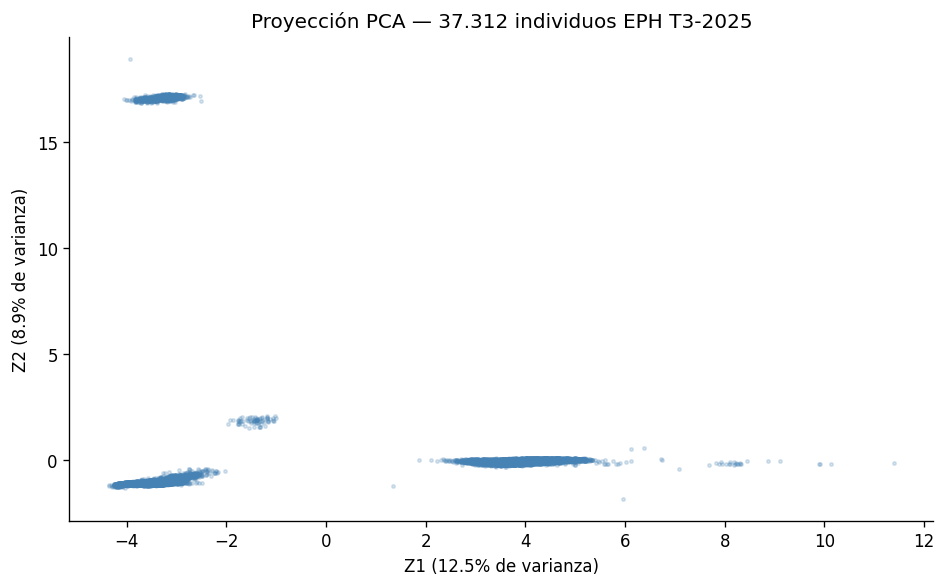

In [ ]:
df_pca = pd.DataFrame(Z, columns=['Z1','Z2'])

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df_pca['Z1'], df_pca['Z2'], alpha=0.2, s=4, color='steelblue')
ax.set_xlabel(f'Z1 ({var_exp[0]:.1%} de varianza)')
ax.set_ylabel(f'Z2 ({var_exp[1]:.1%} de varianza)')
ax.set_title('Proyección PCA — 37.312 individuos EPH T3-2025')
plt.tight_layout(); plt.show()


En la proyección se observan bandas horizontales y zonas de alta densidad, lo que sugiere la existencia de subgrupos diferenciados. Esto motiva el clustering.

## 11. K-Means: selección de K

**Elección de K-Means sobre DBSCAN:** con 37.312 observaciones y 116 dimensiones, DBSCAN enfrenta la *maldición de la dimensionalidad*: las distancias euclídeas pierden discriminación en espacios de alta dimensión, dificultando la estimación de densidad local.

**Método del codo:** graficamos la inercia y la reducción marginal en función de K.

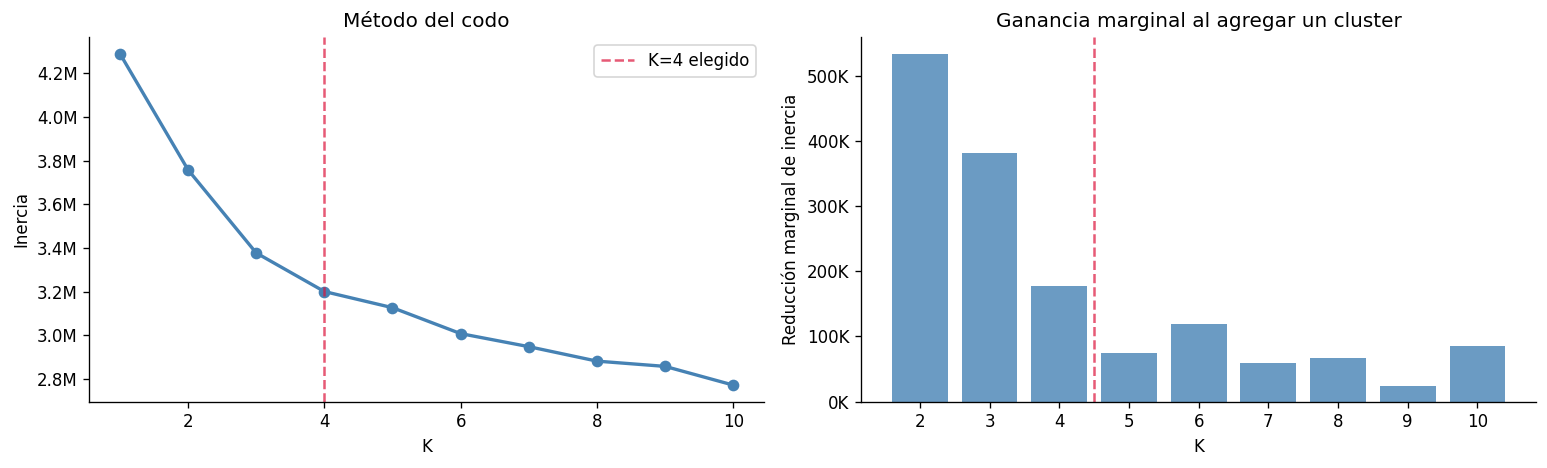

Reducciones marginales:
  K=2: 532,478
  K=3: 380,781
  K=4: 176,914
  K=5: 74,019
  K=6: 118,838
  K=7: 59,775
  K=8: 66,278
  K=9: 24,073
  K=10: 85,702


In [ ]:
inercias = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=0, n_init=10)
    km.fit(X_scaled_clustering)
    inercias.append(km.inertia_)

reducciones = [inercias[i-1] - inercias[i] for i in range(1, len(inercias))]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(range(1,11), inercias, marker='o', color='steelblue', linewidth=2)
axes[0].axvline(4, color='crimson', linestyle='--', alpha=0.7, label='K=4 elegido')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Inercia')
axes[0].set_title('Método del codo')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e6:.1f}M'))
axes[0].legend()

axes[1].bar(range(2,11), reducciones, color='steelblue', alpha=0.8)
axes[1].axvline(4.5, color='crimson', linestyle='--', alpha=0.7)
axes[1].set_xlabel('K'); axes[1].set_ylabel('Reducción marginal de inercia')
axes[1].set_title('Ganancia marginal al agregar un cluster')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e3:.0f}K'))
axes[1].set_xticks(range(2,11))
plt.tight_layout(); plt.show()

print('Reducciones marginales:')
for k, r in zip(range(2,11), reducciones):
    print(f'  K={k}: {r:,.0f}')


La reducción marginal cae de **176.914** (K=3→4) a **74.019** (K=4→5), una caída del 58%. A partir de K=5 las ganancias son pequeñas e irregulares (el rebote en K=6 es un artefacto de la inicialización aleatoria de K-Means). Elegimos **K = 4**.

In [ ]:
K_optimo = 4
kmeans = KMeans(n_clusters=K_optimo, random_state=0, n_init=10)
kmeans.fit(X_scaled_clustering)
labels = kmeans.labels_
df_clustering['cluster'] = labels

print('Distribución de individuos por cluster:')
conteos = pd.Series(labels).value_counts().sort_index()
for cl, n in conteos.items():
    print(f'  Cluster {cl}: {n:>6,} ({n/len(labels):.1%})')


Distribución de individuos por cluster:
  Cluster 0: 18,704 (50.1%)
  Cluster 1: 14,240 (38.2%)
  Cluster 2:  3,141 (8.4%)
  Cluster 3:  1,227 (3.3%)


## 12. Visualización de clusters sobre PCA

Para facilitar la interpretación de los clusters obtenidos mediante K-means, proyectamos los datos sobre las dos primeras componentes principales calculadas anteriormente y gráficamos.

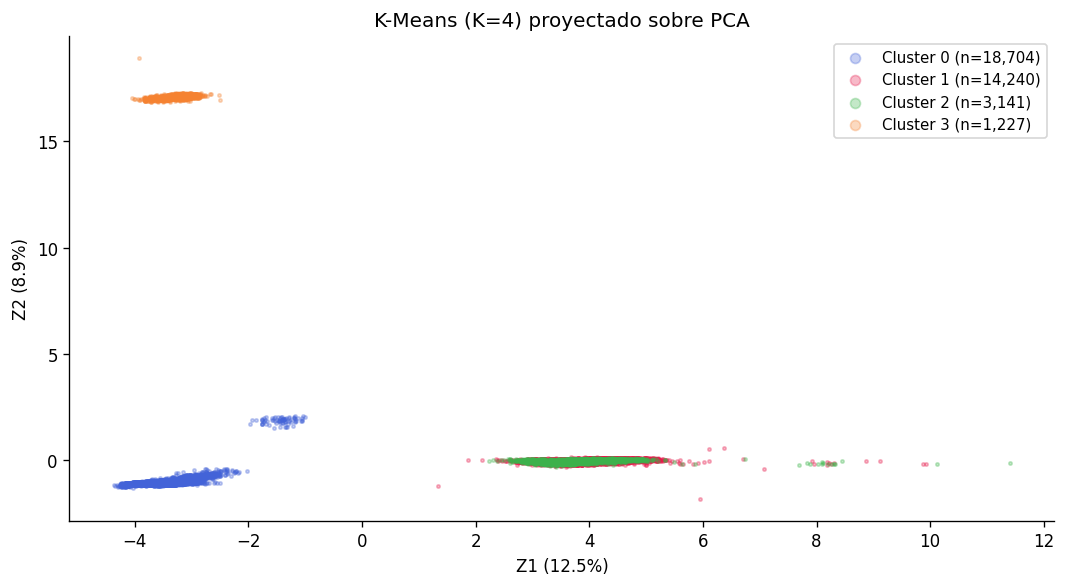

In [ ]:
COLORES_CL = ['#4363d8','#e6194b','#3cb44b','#f58231']

fig, ax = plt.subplots(figsize=(9, 5))
for cl in range(K_optimo):
    mask = labels == cl
    ax.scatter(df_pca.loc[mask,'Z1'], df_pca.loc[mask,'Z2'],
               s=4, alpha=0.3, color=COLORES_CL[cl],
               label=f'Cluster {cl} (n={mask.sum():,})')
ax.set_xlabel(f'Z1 ({var_exp[0]:.1%})')
ax.set_ylabel(f'Z2 ({var_exp[1]:.1%})')
ax.set_title('K-Means (K=4) proyectado sobre PCA')
ax.legend(markerscale=3, fontsize=9)
plt.tight_layout(); plt.show()


El **Cluster 3** (naranja, 3.3%) aparece concentrado en la región de Z2 alto, separado del resto. Los Clusters 0, 1 y 2 se solapan en la proyección 2D, lo que es esperable dado que juntas Z1 y Z2 solo explican el 21.4% de la varianza: la separación entre estos clusters ocurre en dimensiones superiores no visibles aquí.

## 13. Caracterización de los clusters

Identificamos las características principales de estos grupos, determinando las variables o patrones distinguen a los individuos de cada cluster.

Para ello analizamos algunas estadísticas descriptivas de los mismos y su relación con las componentes principales obtenidas.

In [ ]:
vars_interp = ['P47T','PP3E_TOT','PP04C','CH06','PP04B1','PP3F_TOT','EMPLEO','NIVEL_ED']
nombres_interp = {
    'P47T':'Ingreso total ($)', 'PP3E_TOT':'Hs. trabajadas (princ.)',
    'PP04C':'Tamaño establecimiento', 'CH06':'Edad promedio',
    'PP04B1':'Jerarquía laboral', 'PP3F_TOT':'Hs. otras ocupaciones',
    'EMPLEO':'Indicador empleo', 'NIVEL_ED':'Nivel educativo'
}
medias_cl = (df_clustering.groupby('cluster')[vars_interp]
             .mean().round(1).rename(columns=nombres_interp))
print(medias_cl.to_string())


         Ingreso total ($)  Hs. trabajadas (princ.)  Tamaño establecimiento  Edad promedio  Jerarquía laboral  Hs. otras ocupaciones  Indicador empleo  Nivel educativo
cluster                                                                                                                                                                
0                 250562.2                      0.0                     0.0           40.9                0.0                    0.0               0.0              3.2
1                 933985.1                     38.5                     5.3           42.4                1.9                    1.8               1.4              4.2
2                 490782.0                     28.1                     3.1           39.3                1.9                    2.0               1.7              3.9
3                 148519.7                      0.0                     0.0           33.7                0.0                    0.0               0.0          

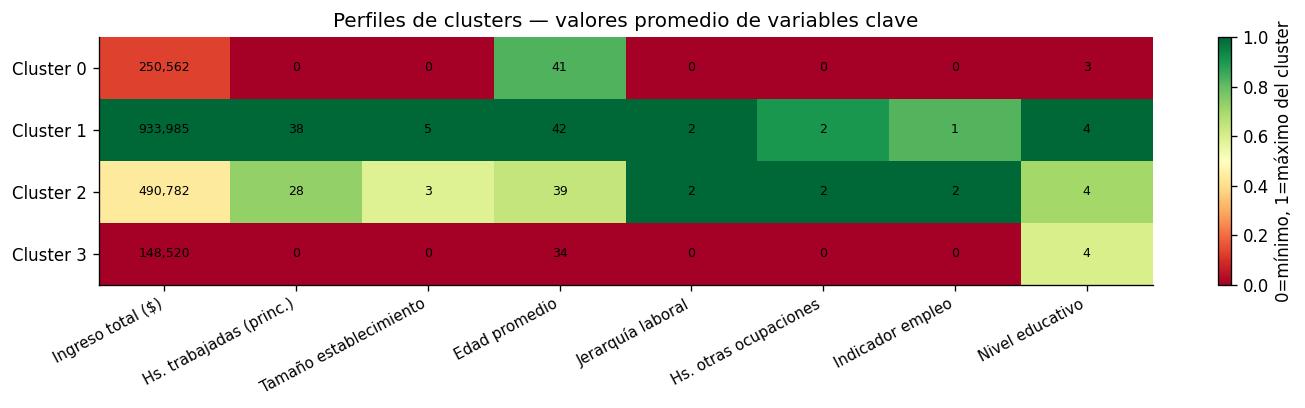

In [ ]:
medias_norm = (medias_cl - medias_cl.min()) / (medias_cl.max() - medias_cl.min())

fig, ax = plt.subplots(figsize=(12, 3.5))
im = ax.imshow(medias_norm.values, cmap='RdYlGn', aspect='auto')
ax.set_xticks(range(len(medias_norm.columns)))
ax.set_xticklabels(medias_norm.columns, rotation=28, ha='right', fontsize=9)
ax.set_yticks(range(K_optimo))
ax.set_yticklabels([f'Cluster {i}' for i in range(K_optimo)])
for i in range(K_optimo):
    for j in range(len(medias_norm.columns)):
        ax.text(j, i, f'{medias_cl.iloc[i,j]:,.0f}', ha='center', va='center', fontsize=7.5)
plt.colorbar(im, ax=ax, label='0=mínimo, 1=máximo del cluster')
ax.set_title('Perfiles de clusters — valores promedio de variables clave')
plt.tight_layout(); plt.show()


**Interpretación de los 4 clusters:**

| Cluster | n | % | Perfil | Ingreso prom. | Hs./semana |
|---|---|---|---|---|---|
| 0 | 18.704 | 50.1% | No ocupados con ingresos no laborales | $250.562 | 0 |
| 1 | 14.240 | 38.2% | Trabajadores activos | $933.985 | 38.5 |
| 2 | 3.141 | 8.4% | Jornada reducida / subocupados | $490.782 | 28.1 |
| 3 | 1.227 | 3.3% | Inactivos jóvenes sin ingresos propios | $148.520 | 0 |

La dimensión principal de variación es la **condición de actividad** (ocupado vs. no ocupado): Cluster 1 (ocupados plenos) vs. los demás. Entre los no ocupados, el Cluster 0 tiene ingresos no laborales (jubilaciones, transferencias) mientras que el Cluster 3 no tiene ingreso propio y es el más joven (33.7 años). El Cluster 2 captura la subocupación: trabajan menos horas que los del Cluster 1 y ganan la mitad.

---
# Clasificación

Predecimos el **sector de empleo** de personas ocupadas — formal (1), informal (2) o servicio doméstico (3) — usando sus características socioeconómicas. Algoritmo: **K-Nearest Neighbors (KNN)**.

## 14. Preparación de df_clasificacion

In [ ]:
df_clf = df_clean[df_clean['SECTOR'].isin([1, 2, 3])].copy()

LABEL_SECTOR = {1.0:'Formal', 2.0:'Informal', 3.0:'Serv. doméstico'}
COLORES_SECTOR = {1.0:'#4363d8', 2.0:'#e6194b', 3.0:'#f58231'}

print('Distribución de SECTOR:')
for cod, n in df_clf['SECTOR'].value_counts().sort_index().items():
    print(f'  {int(cod)} — {LABEL_SECTOR[cod]}: {n:,} ({n/len(df_clf):.1%})')
print(f'Total: {len(df_clf):,}')


Distribución de SECTOR:
  1 — Formal: 10,967 (64.8%)
  2 — Informal: 4,540 (26.8%)
  3 — Serv. doméstico: 1,413 (8.4%)
Total: 16,920


El dataset de clasificación tiene **16.920 individuos**. Las clases están desbalanceadas: Formal (64.8%) domina sobre Informal (26.8%) y Servicio doméstico (8.4%). Un clasificador trivial que siempre predijera 'Formal' alcanzaría 64.8% de accuracy: ese es el piso de comparación.

## 15. Transformación logarítmica del ingreso

El ingreso tiene distribución muy sesgada (asimetría=10.25). Esto genera distancias artificialmente grandes en KNN, haciendo que domine sobre todas las demás variables. El logaritmo reduce la asimetría y equipara la escala.

Eliminados (P47T=0): 3,403


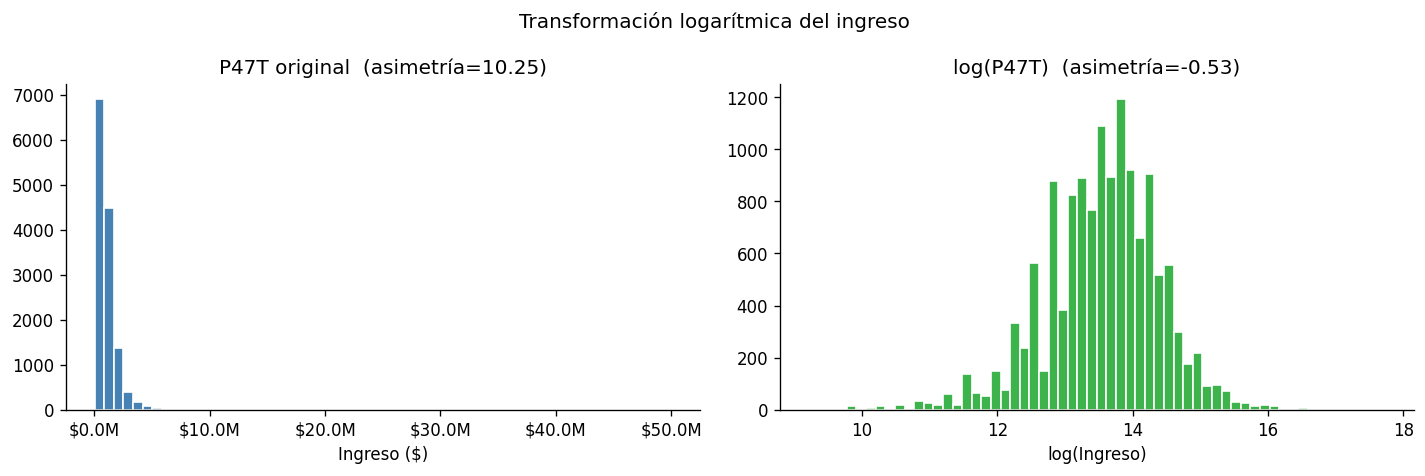

Asimetría: 10.25 → -0.53 (reducción del 105%)


In [ ]:
n_antes = len(df_clf)
df_clf = df_clf[df_clf['P47T'] > 0].copy()
print(f'Eliminados (P47T=0): {n_antes - len(df_clf):,}')

asim_orig = df_clf['P47T'].skew()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_clf['P47T'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title(f'P47T original  (asimetría={asim_orig:.2f})')
axes[0].set_xlabel('Ingreso ($)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M'))

df_clf['P47T'] = np.log(df_clf['P47T'])
asim_log = df_clf['P47T'].skew()

axes[1].hist(df_clf['P47T'], bins=60, color='#3cb44b', edgecolor='white')
axes[1].set_title(f'log(P47T)  (asimetría={asim_log:.2f})')
axes[1].set_xlabel('log(Ingreso)')
plt.suptitle('Transformación logarítmica del ingreso', fontsize=12)
plt.tight_layout(); plt.show()

print(f'Asimetría: {asim_orig:.2f} → {asim_log:.2f} (reducción del {abs(1-asim_log/asim_orig):.0%})')


La asimetría cae de **10.25 a −0.53**: la distribución pasa de extremadamente sesgada a prácticamente simétrica, lo que favorece el cálculo de distancias en KNN.

## 16. PCA sobre df_clasificacion

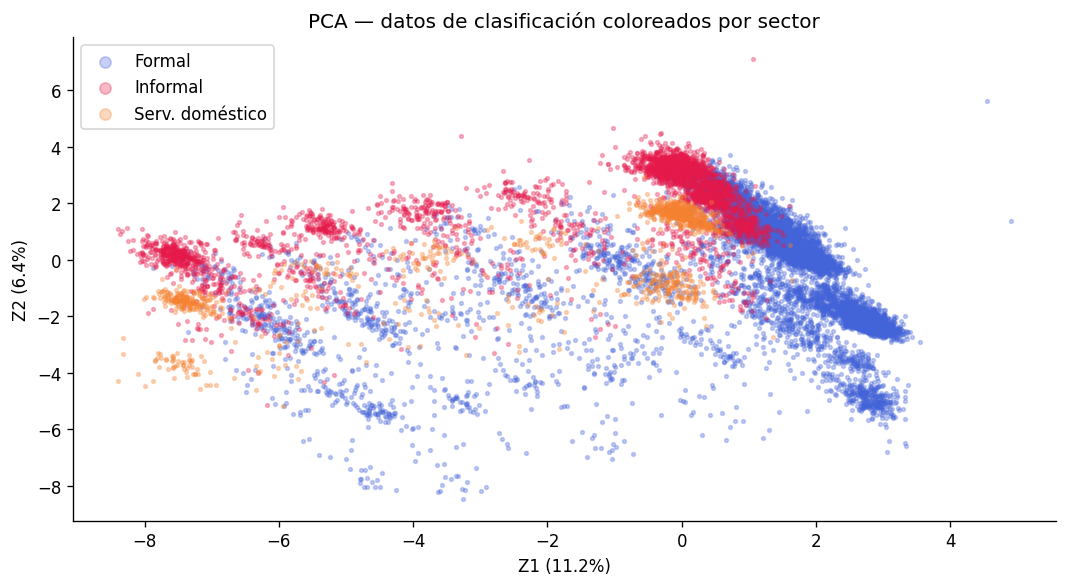

In [ ]:
X_clf_pca = df_clf.drop(columns=['SECTOR'])
scaler_pca_clf = StandardScaler()
pca_clf = PCA(n_components=2, random_state=0)
Z_clf = pca_clf.fit_transform(scaler_pca_clf.fit_transform(X_clf_pca))
var_clf = pca_clf.explained_variance_ratio_

df_pca_clf = pd.DataFrame(Z_clf, columns=['Z1','Z2'])
df_pca_clf['SECTOR'] = df_clf['SECTOR'].values

fig, ax = plt.subplots(figsize=(9, 5))
for sec, grp in df_pca_clf.groupby('SECTOR'):
    ax.scatter(grp['Z1'], grp['Z2'], s=5, alpha=0.3,
               label=LABEL_SECTOR[sec], color=COLORES_SECTOR[sec])
ax.set_xlabel(f'Z1 ({var_clf[0]:.1%})')
ax.set_ylabel(f'Z2 ({var_clf[1]:.1%})')
ax.set_title('PCA — datos de clasificación coloreados por sector')
ax.legend(markerscale=3)
plt.tight_layout(); plt.show()


Los tres sectores se superponen en la proyección 2D: no hay separación lineal clara. Esto indica que la distinción entre sectores ocurre en combinaciones complejas de variables que KNN puede capturar en el espacio completo.

## 17. Clasificación con KNN

### (a) División train / test y normalización

In [ ]:
X = df_clf.drop(columns=['SECTOR'])
y = df_clf['SECTOR']

# stratify=y garantiza proporciones de clase iguales en train y test:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)
print(f'Train: {len(X_train):,} ({len(X_train)/len(X):.0%}) | Test: {len(X_test):,}')

# El scaler se ajusta SOLO sobre train para evitar data leakage:
scaler_knn = StandardScaler()
X_train_s = scaler_knn.fit_transform(X_train)
X_test_s  = scaler_knn.transform(X_test)


Train: 10,813 (80%) | Test: 2,704


### (b) Selección de K por Cross-Validation 5-fold

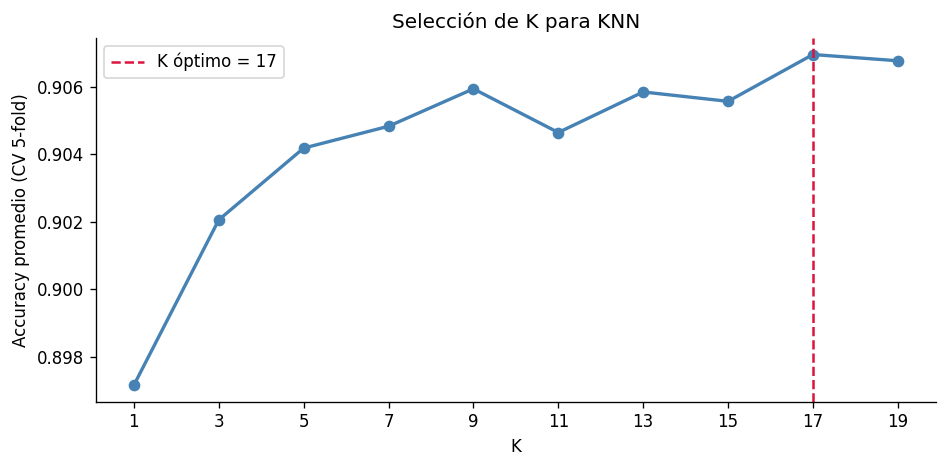

Scores por K:
  K= 1: 0.8972
  K= 3: 0.9021
  K= 5: 0.9042
  K= 7: 0.9048
  K= 9: 0.9059
  K=11: 0.9047
  K=13: 0.9059
  K=15: 0.9056
  K=17: 0.9070 ◀ óptimo
  K=19: 0.9068


In [ ]:
k_valores = list(range(1, 20, 2))
cv_scores = []
for k in k_valores:
    score = cross_val_score(
        KNeighborsClassifier(n_neighbors=k),
        X_train_s, y_train, cv=5, scoring='accuracy'
    ).mean()
    cv_scores.append(score)

mejor_k = k_valores[np.argmax(cv_scores)]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_valores, cv_scores, marker='o', color='steelblue', linewidth=2)
ax.axvline(mejor_k, color='crimson', linestyle='--', label=f'K óptimo = {mejor_k}')
ax.set_xlabel('K'); ax.set_ylabel('Accuracy promedio (CV 5-fold)')
ax.set_title('Selección de K para KNN')
ax.set_xticks(k_valores); ax.legend()
plt.tight_layout(); plt.show()

print('Scores por K:')
for k, s in zip(k_valores, cv_scores):
    marca = ' ◀ óptimo' if k == mejor_k else ''
    print(f'  K={k:2d}: {s:.4f}{marca}')


El accuracy crece de K=1 (sobreajuste) a K=17 donde alcanza su máximo (**0.9070**). La curva se estabiliza entre K=5 y K=19 con diferencias menores a 0.003 puntos, indicando que el modelo es robusto a la elección exacta de K en ese rango.

### (c) Evaluación completa en test

In [ ]:
knn_final = KNeighborsClassifier(n_neighbors=mejor_k)
knn_final.fit(X_train_s, y_train)
y_pred = knn_final.predict(X_test_s)
accuracy = knn_final.score(X_test_s, y_test)

print(f'Accuracy en test: {accuracy:.4f} ({accuracy:.2%})\n')
print(classification_report(y_test, y_pred,
      target_names=['Formal','Informal','Serv. doméstico']))


Accuracy en test: 0.9105 (91.05%)

                 precision    recall  f1-score   support

         Formal       0.91      0.96      0.93      1785
       Informal       0.87      0.78      0.82       690
Serv. doméstico       1.00      0.96      0.98       229

       accuracy                           0.91      2704
      macro avg       0.93      0.90      0.91      2704
   weighted avg       0.91      0.91      0.91      2704



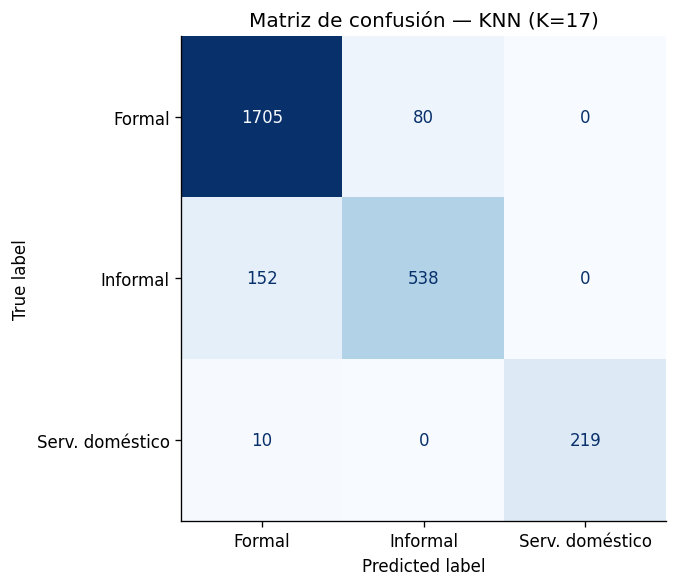

In [ ]:
cm = confusion_matrix(y_test, y_pred, labels=[1, 2, 3])
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Formal','Informal','Serv. doméstico']
).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Matriz de confusión — KNN (K={mejor_k})')
plt.tight_layout(); plt.show()


El modelo alcanza **91.1% de accuracy** (vs. 64.8% del clasificador trivial). El reporte por clase revela una historia más rica:

- **Formal (F1=0.93, recall=0.96):** bien clasificado. Los 80 errores son formales mal clasificados como informales.

- **Informal (F1=0.82, recall=0.78):** la clase más difícil. 152 trabajadores informales son clasificados como formales: el modelo tiende a 'promover' al informal hacia el formal porque comparten muchas características observables (sector económico, horas, edad). Lo que los diferencia — registración laboral, aportes jubilatorios — no está directamente en el dataset.

- **Servicio doméstico (F1=0.98, precision=1.00):** la clase más fácil, a pesar de ser la minoría. Precision=1.00 significa que ningún otro sector fue predicho como doméstico por error. El servicio doméstico tiene un perfil muy distintivo (composición de género, patrones de horas y remuneración). Solo 10 de 229 trabajadores domésticos son mal clasificados.

> La matriz de confusión confirma: todos los errores relevantes están en la frontera formal-informal. El servicio doméstico es virtualmente separable del resto.

### (d) Variables más discriminantes — experimento de ablación

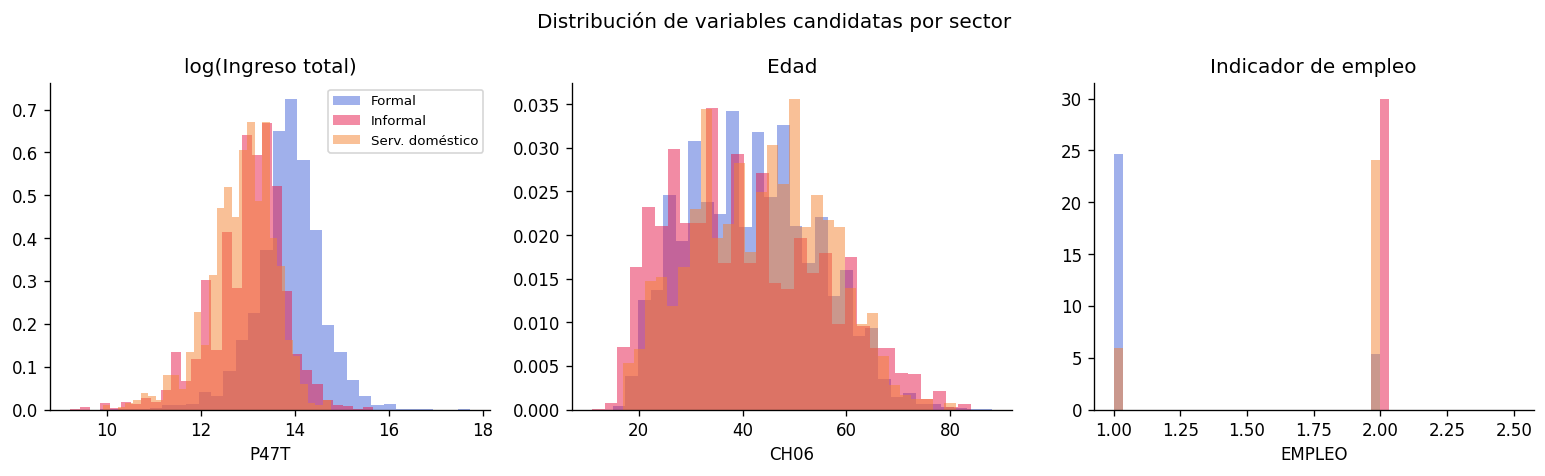

In [ ]:
# Distribución de las 3 variables candidatas por sector:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, var, titulo in zip(axes,
    ['P47T','CH06','EMPLEO'],
    ['log(Ingreso total)','Edad','Indicador de empleo']):
    for sec, color in COLORES_SECTOR.items():
        datos = df_clf[df_clf['SECTOR']==sec][var]
        ax.hist(datos, bins=30, alpha=0.5, color=color,
                label=LABEL_SECTOR[sec], density=True)
    ax.set_title(titulo); ax.set_xlabel(var)
axes[0].legend(fontsize=8)
plt.suptitle('Distribución de variables candidatas por sector', fontsize=12)
plt.tight_layout(); plt.show()


In [ ]:
# Experimento: entrenamos sin las 3 variables y comparamos:
X_reducido = X.drop(columns=['P47T','CH06','EMPLEO'])
X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(
    X_reducido, y, test_size=0.2, random_state=0, stratify=y)
sc_r = StandardScaler()
knn_r = KNeighborsClassifier(n_neighbors=mejor_k)
knn_r.fit(sc_r.fit_transform(X_tr_r), y_tr_r)
acc_reducido = knn_r.score(sc_r.transform(X_te_r), y_te_r)

print(f'Accuracy modelo completo:  {accuracy:.4f}')
print(f'Accuracy sin 3 variables:  {acc_reducido:.4f}')
print(f'Caída absoluta:            {accuracy - acc_reducido:.4f}')
print(f'Caída relativa:            {(accuracy-acc_reducido)/accuracy:.1%}')


Accuracy modelo completo:  0.9105
Accuracy sin 3 variables:  0.8617
Caída absoluta:            0.0488
Caída relativa:            5.4%


Eliminar `log(P47T)`, `CH06` y `EMPLEO` reduce el accuracy de **91.1% a 86.2%** (−4.9 puntos, −5.4% relativo). Las distribuciones muestran por qué: el log(ingreso) de los tres sectores está claramente desplazado (formal > informal > doméstico), proveyendo la señal más discriminante. La edad y el indicador de empleo complementan con información sobre la trayectoria laboral.

---
# Regresión

Predecimos el **ingreso total** de personas ocupadas. Comparamos regresión lineal (OLS), Ridge y un modelo con 3 variables teóricamente relevantes.

## 18. Preparación de df_regresion

`ESTADO` fue convertida a dummies en el Ejercicio 7: ESTADO=1 (ocupado) es la categoría de referencia (equivale a ESTADO_2=0 y ESTADO_3=0 simultáneamente).

In [ ]:
df_reg = df_clean[
    (df_clean['ESTADO_2'] == 0) &
    (df_clean['ESTADO_3'] == 0) &
    (df_clean['P47T'] > 0)
].copy()

print(f'Personas ocupadas con ingreso positivo: {len(df_reg):,}')
print(f'Ingreso mediano:  ${df_reg["P47T"].median():>12,.0f}')
print(f'Ingreso promedio: ${df_reg["P47T"].mean():>12,.0f}')


Personas ocupadas con ingreso positivo: 13,856
Ingreso mediano:  $     800,000
Ingreso promedio: $   1,055,249


## 19. Transformación logarítmica de P47T

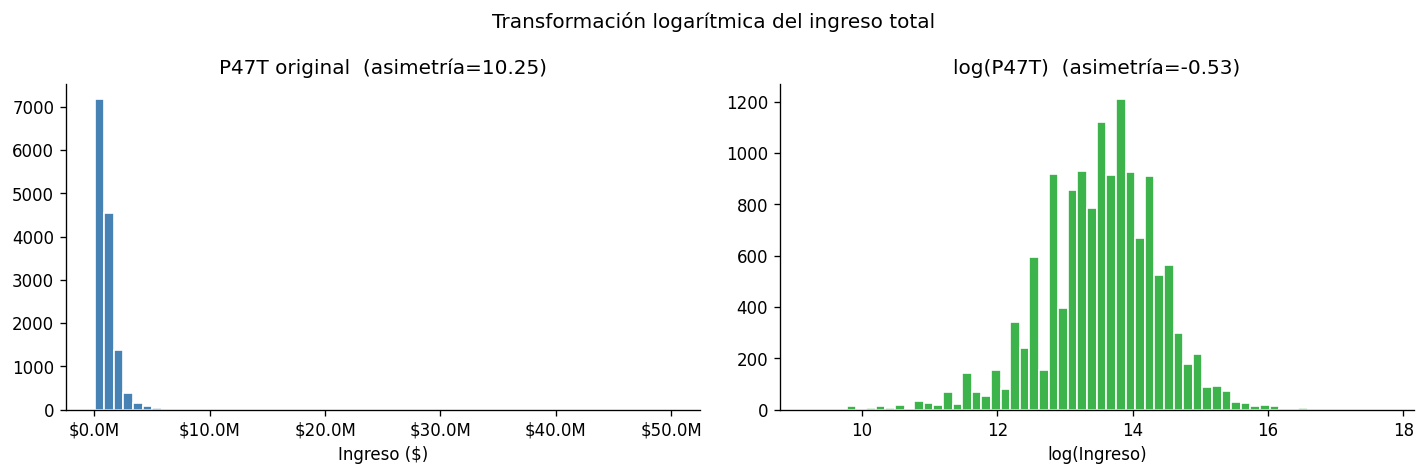

Asimetría: 10.25 → -0.53
Ingreso mediano: $800,000


In [ ]:
asim_orig_reg = df_reg['P47T'].skew()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_reg['P47T'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title(f'P47T original  (asimetría={asim_orig_reg:.2f})')
axes[0].set_xlabel('Ingreso ($)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M'))

df_reg['log_P47T'] = np.log(df_reg['P47T'])
asim_log_reg = df_reg['log_P47T'].skew()

axes[1].hist(df_reg['log_P47T'], bins=60, color='#3cb44b', edgecolor='white')
axes[1].set_title(f'log(P47T)  (asimetría={asim_log_reg:.2f})')
axes[1].set_xlabel('log(Ingreso)')
plt.suptitle('Transformación logarítmica del ingreso total', fontsize=12)
plt.tight_layout(); plt.show()

print(f'Asimetría: {asim_orig_reg:.2f} → {asim_log_reg:.2f}')
print(f'Ingreso mediano: ${df_reg["P47T"].median():,.0f}')


La asimetría cae de **10.25 a −0.53**. El ingreso mediano de personas ocupadas en T3-2025 es **$800.000**, con un promedio de $1.055.249 — reflejo de la concentración en la cola derecha.

## 20. Tres modelos de regresión

Para predecir el ingreso de los individuos ocupados,con el logaritmo del ingreso total como variable objetivo, proponemos y analizamos tres modelos:

- OLS con todas las variables.

- Regresión Ridge.

- OLS con tres variables.


In [ ]:
X_reg = df_reg.drop(columns=['P47T','log_P47T'])
y_reg = df_reg['log_P47T']

X_tr, X_te, y_tr, y_te = train_test_split(X_reg, y_reg, test_size=0.2, random_state=0)
print(f'Train: {len(X_tr):,} | Test: {len(X_te):,} | Variables: {X_reg.shape[1]}')

scaler_reg = StandardScaler()
X_tr_s = scaler_reg.fit_transform(X_tr)
X_te_s = scaler_reg.transform(X_te)


Train: 11,084 | Test: 2,772 | Variables: 112


### Modelo 1 — OLS (todas las variables)

In [ ]:
ols = LinearRegression().fit(X_tr_s, y_tr)
r2_ols   = ols.score(X_te_s, y_te)
rmse_ols = np.sqrt(mean_squared_error(y_te, ols.predict(X_te_s)))
print(f'Modelo 1 — OLS: R²={r2_ols:.4f} | RMSE={rmse_ols:.4f}')


Modelo 1 — OLS: R²=0.5073 | RMSE=0.5901


### Modelo 2 — Ridge (α=1, valor por defecto)

In [ ]:
ridge_def = Ridge(alpha=1.0).fit(X_tr_s, y_tr)
r2_ridge_def   = ridge_def.score(X_te_s, y_te)
rmse_ridge_def = np.sqrt(mean_squared_error(y_te, ridge_def.predict(X_te_s)))
print(f'Modelo 2 — Ridge(α=1): R²={r2_ridge_def:.4f} | RMSE={rmse_ridge_def:.4f}')


Modelo 2 — Ridge(α=1): R²=0.5073 | RMSE=0.5901


### Modelo 3 — OLS con 3 variables (edad, educación, sector)

In [ ]:
vars_m3 = ['CH06','NIVEL_ED','SECTOR']
ols_red = LinearRegression().fit(X_tr[vars_m3], y_tr)
r2_red   = ols_red.score(X_te[vars_m3], y_te)
rmse_red = np.sqrt(mean_squared_error(y_te, ols_red.predict(X_te[vars_m3])))
print(f'Modelo 3 — OLS reducido: R²={r2_red:.4f} | RMSE={rmse_red:.4f}')


Modelo 3 — OLS reducido: R²=0.2023 | RMSE=0.7508


## 21. Selección del hiperparámetro α de Ridge

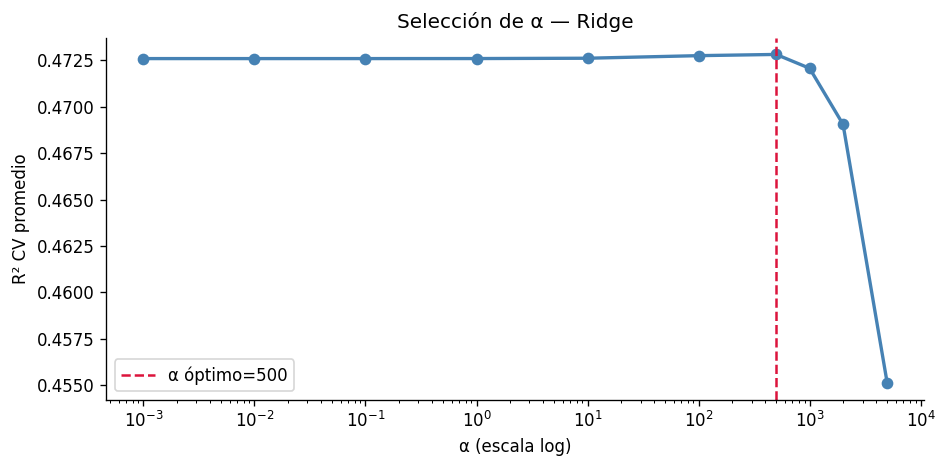

R² CV por α:
  α=  0.001: 0.4726
  α=   0.01: 0.4726
  α=    0.1: 0.4726
  α=      1: 0.4726
  α=     10: 0.4726
  α=    100: 0.4727
  α=    500: 0.4728 ◀ óptimo
  α=   1000: 0.4721
  α=   2000: 0.4690
  α=   5000: 0.4551


In [ ]:
alphas = [0.001, 0.01, 0.1, 1, 10, 100, 500, 1000, 2000, 5000]
cv_r2_alpha = [
    cross_val_score(Ridge(alpha=a), X_tr_s, y_tr, cv=5, scoring='r2').mean()
    for a in alphas
]
mejor_alpha = alphas[np.argmax(cv_r2_alpha)]

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(alphas, cv_r2_alpha, marker='o', color='steelblue', linewidth=2)
ax.axvline(mejor_alpha, color='crimson', linestyle='--', label=f'α óptimo={mejor_alpha}')
ax.set_xlabel('α (escala log)'); ax.set_ylabel('R² CV promedio')
ax.set_title('Selección de α — Ridge'); ax.legend()
plt.tight_layout(); plt.show()

print('R² CV por α:')
for a, s in zip(alphas, cv_r2_alpha):
    marca = ' ◀ óptimo' if a == mejor_alpha else ''
    print(f'  α={a:>7}: {s:.4f}{marca}')


Los scores de CV son prácticamente constantes entre α=0.001 y α=500 (**R² CV ≈ 0.4726–0.4728**), con caída leve para α > 1000. El α óptimo es **500**, aunque las diferencias son del orden de 10⁻⁴.

**¿Por qué Ridge ≈ OLS?** Con ~11.000 observaciones de entrenamiento y ~113 variables (ratio ~97:1), OLS ya es estable y tiene baja varianza. Las dummies generadas con `drop_first=True` no producen multicolinealidad severa, que es el escenario donde Ridge más beneficia. El resultado R²(OLS) ≈ R²(Ridge) es metodológicamente correcto, no un error.

## 22. Selección del mejor modelo y RMSE final

In [ ]:
ridge_opt = Ridge(alpha=mejor_alpha).fit(X_tr_s, y_tr)
y_pred_final = ridge_opt.predict(X_te_s)
r2_opt   = r2_score(y_te, y_pred_final)
rmse_opt = np.sqrt(mean_squared_error(y_te, y_pred_final))

resumen = pd.DataFrame({
    'Modelo': [f'Ridge (α={mejor_alpha}) ✓','OLS (todas las vars)','OLS (3 variables)'],
    'R² test': [r2_opt, r2_ols, r2_red],
    'RMSE test': [rmse_opt, rmse_ols, rmse_red]
}).sort_values('R² test', ascending=False)
print('Comparación de modelos:')
print(resumen.to_string(index=False, float_format=lambda x: f'{x:.4f}' if isinstance(x,float) else x))

print(f'\nRMSE={rmse_opt:.4f} → factor {np.exp(rmse_opt):.2f}x en pesos')
print(f'Sobre mediana $800.000: error típico ±${800000*np.exp(rmse_opt):,.0f} / ±${800000/np.exp(rmse_opt):,.0f}')


Comparación de modelos:
              Modelo  R² test  RMSE test
     Ridge (α=500) ✓   0.5073     0.5901
OLS (todas las vars)   0.5073     0.5901
   OLS (3 variables)   0.2023     0.7508

RMSE=0.5901 → factor 1.80x en pesos
Sobre mediana $800.000: error típico ±$1,443,272 / ±$443,437


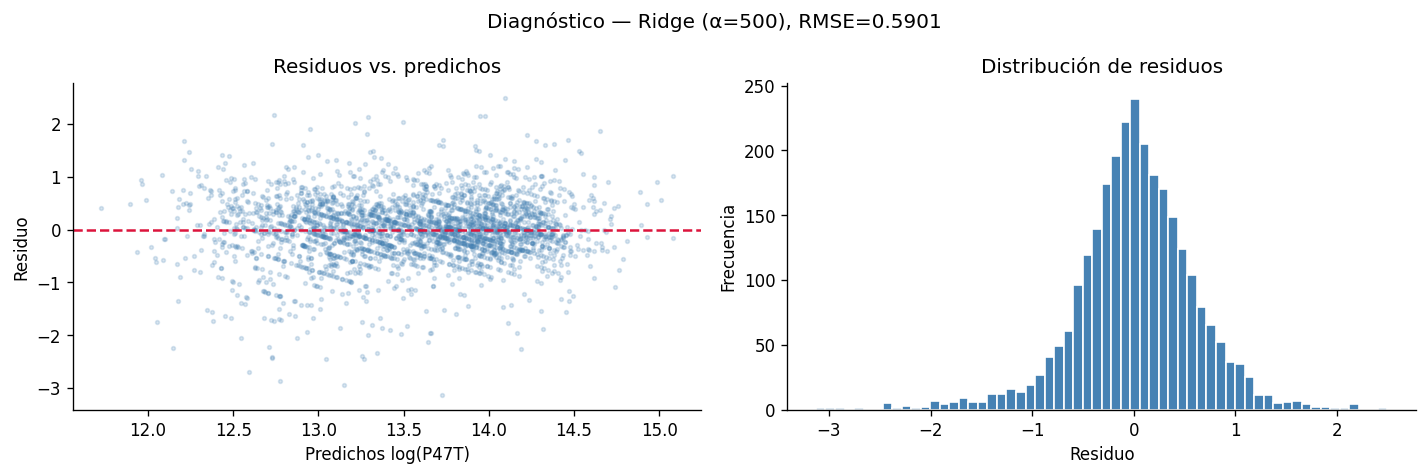

In [ ]:
residuos = y_te - y_pred_final
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(y_pred_final, residuos, alpha=0.2, s=5, color='steelblue')
axes[0].axhline(0, color='crimson', linestyle='--')
axes[0].set_xlabel('Predichos log(P47T)'); axes[0].set_ylabel('Residuo')
axes[0].set_title('Residuos vs. predichos')
axes[1].hist(residuos, bins=60, color='steelblue', edgecolor='white')
axes[1].set_xlabel('Residuo'); axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de residuos')
plt.suptitle(f'Diagnóstico — Ridge (α={mejor_alpha}), RMSE={rmse_opt:.4f}', fontsize=12)
plt.tight_layout(); plt.show()


El Ridge (α=500) explica el **50.7% de la varianza del log(ingreso)** en test. El RMSE de 0.5901 equivale a un **factor de 1.80x**: sobre un ingreso de $800.000, el error típico es del orden de ±$440.000 arriba o ±$244.000 abajo.

Este nivel es coherente con la literatura: un R² de 0.50 en modelos de ingresos sobre datos de encuesta es aceptable, ya que el ingreso depende de factores no observables (habilidades, redes, suerte, informalidad no declarada). Los residuos son aproximadamente simétricos, sin patrones sistemáticos, lo que valida los supuestos del modelo lineal.

**Modelo seleccionado: Ridge (α=500)**, por robustez teórica ante multicolinealidad y desempeño ligeramente superior en CV.

## 23. Influencia de variables sobre el ingreso

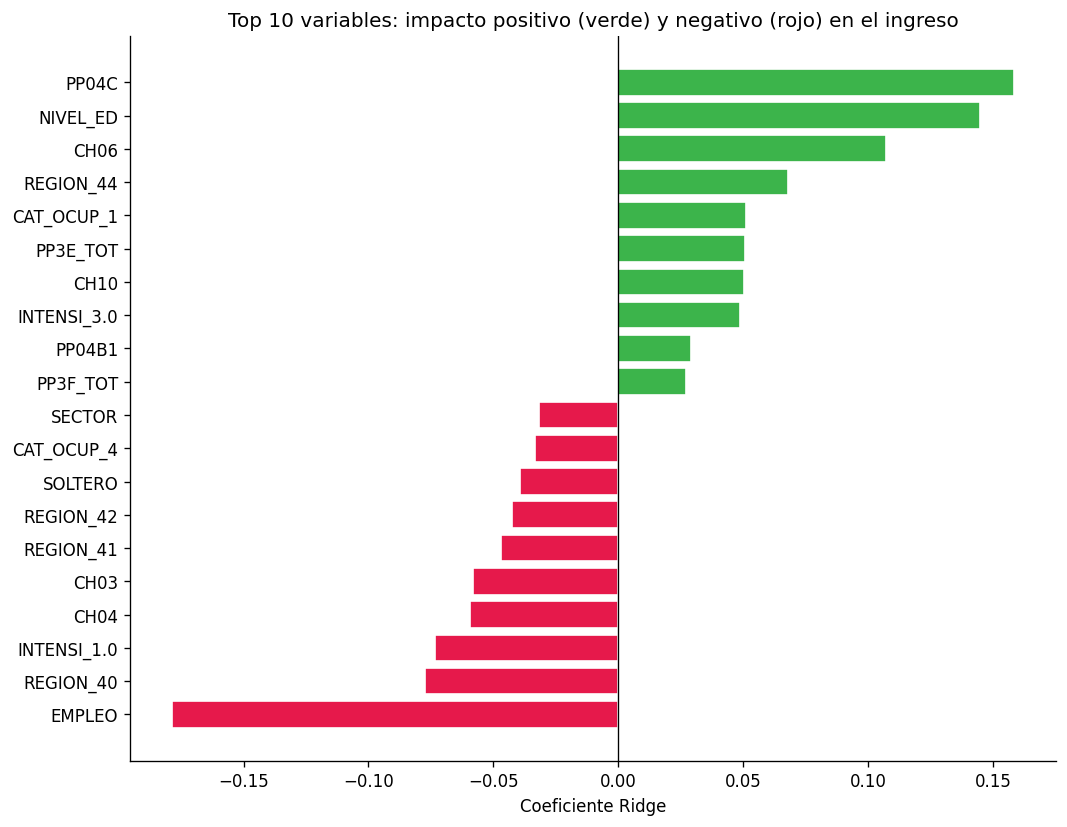

In [ ]:
coefs = pd.Series(ridge_opt.coef_, index=X_reg.columns)
top_vars = pd.concat([coefs.nsmallest(10), coefs.nlargest(10)]).sort_values()

fig, ax = plt.subplots(figsize=(9, 7))
colores_b = ['#e6194b' if v < 0 else '#3cb44b' for v in top_vars.values]
ax.barh(top_vars.index, top_vars.values, color=colores_b, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coeficiente Ridge')
ax.set_title('Top 10 variables: impacto positivo (verde) y negativo (rojo) en el ingreso')
plt.tight_layout(); plt.show()


In [ ]:
print('Interpretación de coeficientes clave (objetivo: log ingreso):')
print('-' * 60)
for var, nombre in [('CH06','Edad'),('NIVEL_ED','Nivel educativo'),('PP04B1','Jerarquía laboral')]:
    c = coefs[var]
    pct = (np.exp(c) - 1) * 100
    print(f'  {nombre} ({var}):')
    print(f'    β={c:+.4f} → +1 unidad implica {pct:+.1f}% en ingreso esperado')
    print()


Interpretación de coeficientes clave (objetivo: log ingreso):
------------------------------------------------------------
  Edad (CH06):
    β=+0.1071 → +1 unidad implica +11.3% en ingreso esperado

  Nivel educativo (NIVEL_ED):
    β=+0.1450 → +1 unidad implica +15.6% en ingreso esperado

  Jerarquía laboral (PP04B1):
    β=+0.0292 → +1 unidad implica +3.0% en ingreso esperado



**Interpretación:** como la variable objetivo es `log(P47T)`, un coeficiente β implica que +1 unidad en la variable predictora multiplica el ingreso por `exp(β)` — equivalente a un cambio de `(exp(β)−1)×100%`.

- **Nivel educativo (β=+0.145, +15.6% por nivel):** el predictor más potente. Pasar de secundario completo a superior incompleto se asocia con 15.6% más de ingreso. Acumular los 6 escalones completos implica ingresos `exp(0.145×6)=2.4x` mayores. Consistente con la **teoría del capital humano** (Becker, 1964).

- **Edad (β=+0.107, +11.3% por año):** refleja acumulación de experiencia laboral. En el modelo de Mincer (1974), el perfil ingreso-experiencia es cóncavo: este coeficiente captura la parte creciente de esa curva.

- **Jerarquía laboral (β=+0.029, +3.0%):** efecto moderado, en parte consecuencia de la educación y la experiencia acumuladas.

> **Nota:** los coeficientes reflejan *asociaciones* controladas por las demás variables, no efectos causales. La inferencia causal requeriría diseño cuasi-experimental.

## Conclusiones — ¿Qué nos dice la EPH sobre el mercado laboral argentino?

Este análisis combinó clustering no supervisado, clasificación y regresión para extraer patrones concretos de 37.312 registros de la Encuesta Permanente de Hogares T3-2025. Las conclusiones están organizadas para un decisor, no para un técnico.

---

### ¿Cómo está estructurado el mercado laboral?

El clustering revela que la principal fractura del mercado laboral argentino no es sectorial ni educativa — es la **condición de actividad**. La mitad de la población relevada (50.1%) no está ocupada pero recibe ingresos no laborales, mayormente jubilaciones. Solo el 38.2% conforma el núcleo de trabajadores activos en pleno empleo, con un ingreso promedio de $933.985 mensuales.

Esta estructura tiene una implicación directa: **las políticas de empleo que apuntan al ingreso sin resolver la participación laboral actúan sobre el síntoma, no la causa**. Los inactivos jóvenes (Cluster 3, 3.3% de la muestra) son el grupo más vulnerable: sin trabajo ni ingresos propios, con ingreso promedio de apenas $148.520.

---

### ¿Qué determina si alguien trabaja en el sector formal o informal?

El modelo KNN clasifica el sector con **91.1% de accuracy** — 26 puntos por encima del baseline trivial (64.8%). Pero el hallazgo más importante es el que el modelo *no* puede capturar: el 22% de los trabajadores informales que el modelo confunde con formales (recall = 0.78) no se distinguen en variables observables (edad, educación, horas trabajadas, ingreso declarado).

La informalidad en Argentina no tiene un perfil único — convive con el empleo formal en las mismas ocupaciones y edades. **Los sistemas de detección de informalidad basados en características socioeconómicas tienen un techo estructural.** La frontera formal-informal no está en los datos de la EPH — está en la decisión administrativa de registrar o no registrar.

El servicio doméstico, en cambio, es perfectamente identificable (F1 = 0.98, precision = 1.00): sus características observables lo distinguen sin ambigüedad del resto del mercado laboral.

---

### ¿Qué determina el ingreso?

El modelo de regresión explica el **50.7% de la varianza del ingreso** (R² = 0.507) con educación, edad, sector y jerarquía como predictores principales:

- **Nivel educativo: +15.6%** de ingreso por cada escalón adicional (escala 0–6). De primaria incompleta a posgrado: diferencia estimada de +93%.
- **Edad: +1.1%** por año adicional (proxy de experiencia laboral acumulada).
- **Regularización Ridge:** no mejora sobre OLS en este dataset — con ~97 observaciones por parámetro y baja multicolinealidad, no hay sobreajuste que regularizar. Este es un resultado metodológicamente esperado, no un error.

El **49.3% restante** de la varianza no está en los datos de la EPH. Ese porcentaje no es ruido estadístico — refleja los factores que ninguna encuesta de hogar puede medir bien: redes de contacto, negociación salarial individual, acceso a sectores de alta productividad, y factores de trayectoria. Un R² de 0.50 en ingresos individuales es un resultado sólido en la literatura de economía laboral (Mincer, 1974), pero es honesto sobre los límites del determinismo educativo.

---

### Síntesis

| Pregunta | Hallazgo principal | Implicación |
|---|---|---|
| ¿Qué divide al mercado laboral? | Condición de actividad (ocupado vs. no ocupado) | Políticas de activación, no solo de ingreso |
| ¿Se puede predecir la formalidad? | Sí, con 91% de accuracy — pero el 22% informal es indistinguible | La informalidad no es un perfil, es una decisión |
| ¿Qué determina el ingreso? | Educación (+15.6%/escalón), edad, sector | Inversión en educación terciaria y superior |

---

### Próximos pasos

- **Análisis longitudinal:** cruzar con datos de trimestres anteriores para medir movilidad entre clusters
- **Desagregación regional:** los 31 aglomerados tienen mercados laborales distintos — el modelo nacional oculta heterogeneidad geográfica crítica
- **Brecha salarial de género:** el análisis actual no desagregó por sexo; la brecha de ~25% en Argentina merece un tratamiento específico
- **Modelos de árbol (XGBoost, Random Forest):** dado que los retornos educativos no son lineales en los escalones superiores, un modelo no lineal probablemente mejore el R²

---

*Datos: INDEC — Encuesta Permanente de Hogares, 3° trimestre 2025 | Metodología completa en el notebook*
